<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [2]:
from google.colab import files
uploaded = files.upload()

Saving stock_price.csv to stock_price.csv


In [3]:
df = pd.read_csv('stock_price.csv')

print(df.head())

data = df.iloc[:,1:2].values

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

     Month   Sales
0  2015-01  209.93
1  2015-02  215.33
2  2015-03  247.60
3  2015-04  278.71
4  2015-05  253.11


In [4]:
def create_dataset(dataset, time_step=1):

    X, Y = [], []

    for i in range(len(dataset)-time_step-1):

        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(Y)

In [5]:
time_step = 10

X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

model = Sequential()

model.add(LSTM(
    50,
    return_sequences=True,
    input_shape=(time_step,1)
))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2029
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0387
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0317
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0234
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0216
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0198
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0181
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0181
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0174
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0174
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0171
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0168
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0166
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0166
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0162
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━

In [7]:
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

original_data = scaler.inverse_transform(scaled_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step


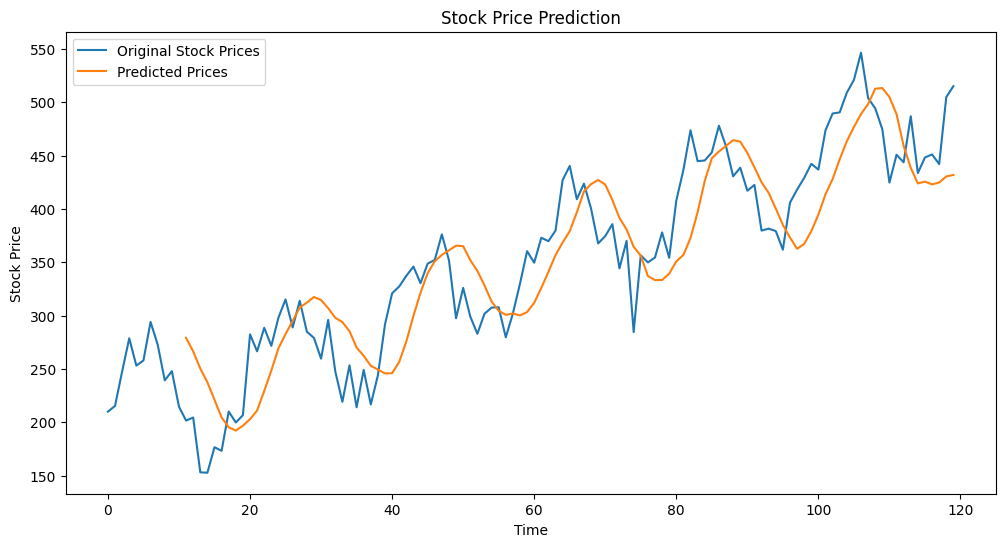

In [8]:
plt.figure(figsize=(12,6))

plt.plot(original_data, label='Original Stock Prices')

plt.plot(
    range(time_step+1, time_step+1+len(predictions)),
    predictions,
    label='Predicted Prices'
)

plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()